# 02 · Feature engineering as a research gate

**Question:** Which representations improve transfer to an unseen policy, and can we explain why?

This notebook follows the expanded four-policy study from its committed protocol to screening, matched ablations and robustness. It uses fixed classifiers to isolate representation choices. The leading frozen centroid reaches 0.7042 transfer AUC versus 0.4728 for the matched lexical reference; compact semantic comparisons give the strongest family addition. Retrieval and shorter embedding prefixes do not improve the leading representation. Development evidence still needs a stopping decision and independent confirmation.

In [1]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
from jigsaw_rules.review import public_evidence
from jigsaw_rules.runtime import environment

root = Path(os.environ.get("JIGSAW_ROOT", Path.cwd())).resolve()
if root.name == "notebooks":
    root = root.parent
baseline = public_evidence(root, "baseline")
semantic = public_evidence(root, "semantic")
assert baseline["training_sha256"] == semantic["training_sha256"]
print("Historical references: 2,029 rows, two policies; expanded research is a separate cohort.")
print("Aggregate checksums verified. This notebook performs no model fitting.")
protocols = {"seen_rule": "Familiar rules", "heldout_rule": "Held-out rule"}

def metric_table(records, heldout=False):
    return pd.DataFrame([{"Representation": r["model"], "Validation": protocols[r["protocol"]],
        "Rule macro AUC": r["metrics"]["rule_macro_auc"],
        "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"],
        "Average precision": r["metrics"]["average_precision"]}
        for r in records if not heldout or r["protocol"] == "heldout_rule"]).round(4)


Historical references: 2,029 rows, two policies; expanded research is a separate cohort.
Aggregate checksums verified. This notebook performs no model fitting.


In [2]:
import sys
sys.path.insert(0, str(root / "scripts"))
from build_research_report import display_figure
from build_release_report import display_boundary
from jigsaw_rules.features import feature_evidence
from jigsaw_rules.research import research_evidence
from jigsaw_rules.diagnostics import diagnostic_evidence
from jigsaw_rules.pairs import pairs_evidence
from jigsaw_rules.robustness import robustness_evidence
from jigsaw_rules.gate import feature_gate
from jigsaw_rules.instructions import instruction_evidence
from jigsaw_rules.released import released_evidence
from jigsaw_rules.expanded import expanded_evidence
from jigsaw_rules.retrieval import retrieval_evidence
from jigsaw_rules.resolution import resolution_evidence
from build_expanded_report import display_figure as display_expanded

expanded = expanded_evidence(root)
retrieval = retrieval_evidence(root)
resolution = resolution_evidence(root)
assert expanded is not None and retrieval is not None and resolution is not None
controls = feature_evidence(root)
research = research_evidence(root)
sensitivity = diagnostic_evidence(root)
pairs = pairs_evidence(root)
robustness = robustness_evidence(root)
assert all(item is not None for item in (controls, research, sensitivity, pairs, robustness))
gate = feature_gate(root)
instructions = instruction_evidence(root)
released = released_evidence(root)
assert released is not None
print("Verified expanded study:", expanded["metadata"]["run_id"])


Verified expanded study: a57bb74350fcbcd66592


## 1 · The research question and protected boundary
The historical search covered two policies. The host's released corpus now permits 11,135 development rows across advertising, legal advice, medical advice and illegal-activity promotion. The 43,576 reserved rows include financial advice and spoilers, whose labels remain outside research. [Pre-score protocol](../docs/EXPANDED_STUDY.md) · [Data provenance](../docs/RELEASED_DATA.md).

Use three familiar-policy grouped folds and four held-out-policy folds. Every training body and supplied example is checked against validation bodies. Retain repeated annotations in the primary experiment; handle their influence through grouped validation and declared sensitivity analyses.

In [3]:
audit = expanded["audit"]
print("Protocol commit:", expanded["metadata"]["protocol_commit"])
print("Development rows / policies:", audit["development_rows"], audit["development_policies"])
print("Primary / total fitted models:", audit["primary_fitted_models"], audit["actual_fitted_models"])
print("Confirmation labels accessed:", audit["confirmation_labels_accessed"])
display(pd.DataFrame(audit["folds"])[["protocol", "fold", "training_rows", "validation_rows", "purged_training_rows"]])

Protocol commit: 5c16f91c04880d52280bf5a0a71ff688b327bb70
Development rows / policies: 11135 4
Primary / total fitted models: 238 260
Confirmation labels accessed: False


,protocol,fold,training_rows,validation_rows,purged_training_rows
0,seen_rule,0,3000,3712,4423
1,seen_rule,1,2643,3712,4780
2,seen_rule,2,2936,3711,4488
3,heldout_rule,0,5277,3152,2706
4,heldout_rule,1,5925,3383,1827
5,heldout_rule,2,8418,2389,328
6,heldout_rule,3,8289,2211,635


## 2 · Search broadly, with a reason for each family
Words and character patterns capture phrasing and morphology. Style measures test requests, links and emphasis. Rule/support similarities, token products and semantic geometry test whether the comment resembles prohibited examples more than permitted ones. Training-reference ranks test relative position; community frequencies and cross-fitted target context test group effects and shortcut risk.

The encoder is already rule-conditioned. Its raw coordinates, support products and compact scalar comparisons are separate representations. Full-vocabulary, NB-weighted and five fixed SVD controls test whether screening or representation scale explains an apparent gain. [Detailed family rationale, availability and leakage analysis](../docs/FEATURE_RESEARCH.md#candidate-space-and-availability).

No timestamps, author histories, threads, opponents, coaches or ratings exist in the schema. Temporal and historical sports/customer-style features would invent unavailable information.

All candidates  All retained  All rejected
protocol     fold                                            
heldout_rule 0             188519          9451        179068
             1             188521          9356        179165
             2             188521          9582        178939
             3             188521          9613        178908
seen_rule    0             188520          9247        179273
             1             188519          9234        179285
             2             188518          9273        179245

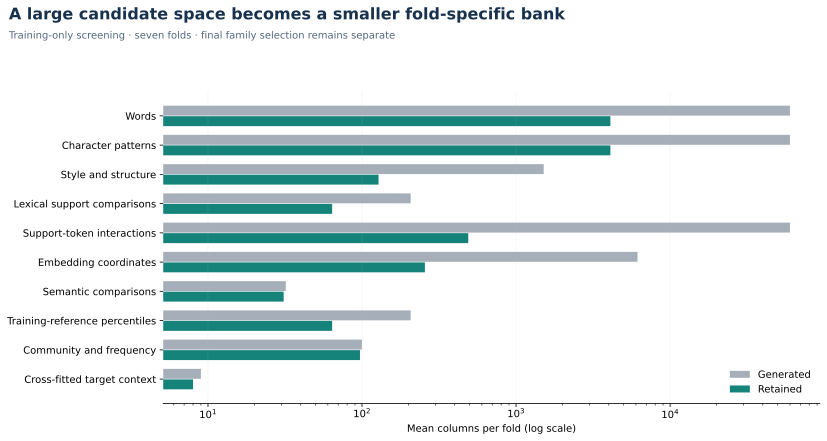

In [4]:
screens = pd.DataFrame(expanded["screening"]["families"])
assert (screens.candidates == screens.retained + screens.rejected).all()
totals = screens.groupby(["protocol", "fold"])[["candidates", "retained", "rejected"]].sum()
extra = pd.DataFrame(retrieval["screening"]).set_index(["protocol", "fold"])[["candidates", "retained", "rejected"]]
display((totals + extra).rename(columns={"candidates": "All candidates", "retained": "All retained", "rejected": "All rejected"}))
display_expanded(root, "screening")

## 3 · Fit every learned transform inside training
Vocabulary/IDF, rarity and redundancy decisions, effect-score screening, scaling, ranks, NB weights and SVD use the purged outer-training rows. Target/context features use inner grouped cross-fitting and inner text purging. Unknown groups fall back to inner-training priors. No validation target selects a column.

A retained bank is not a final feature set: each model consumes only its declared families. The full candidate catalogs, selected names and training IDs remain checksummed private artifacts. Logistic regression stays at C=2; no hyperparameter search compensates for weak representations.

In [5]:
decisions = pd.DataFrame([{"protocol": row["protocol"], "fold": row["fold"], "family": row["family"], **row["decisions"]} for row in expanded["screening"]["families"]]).fillna(0)
display(decisions.drop(columns=["protocol", "fold"]).groupby("family").sum().astype(int))

,rare,screen_budget,constant_or_near_constant,retained,exact_duplicate,high_training_correlation
family,,,,,,
character,123446,142553,60124,28672,65205,0
community,20,0,0,679,0,0
lexical,0,1000,0,448,0,1
ranks,0,753,0,448,239,9
semantic,0,41216,0,1792,0,0
semantic_scalar,0,0,0,217,0,7
structure,0,6844,2394,896,214,236
support_tokens,7441,0,409064,3428,67,0
target_context,0,0,7,56,0,0


## 4 · Attribute improvement through matched additions and removals
Each addition starts from the same screened-word model. Each removal starts from the same all-transfer representation. These contrasts test incremental utility, while comparisons with the historical-style reference also change representation/scaling conventions. Paired normalized-body bootstrap draws share weights across models; simultaneous intervals cover the declared contrasts. They condition on fixed OOF predictions and four observed policies, not arbitrary future rules or all adaptive research decisions.

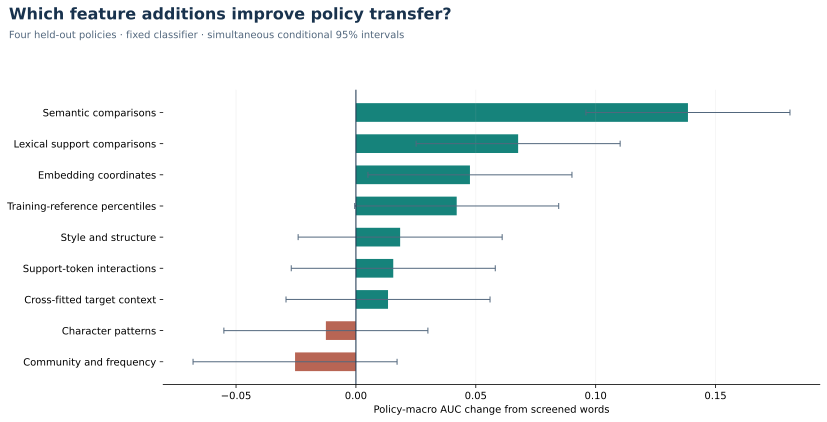

,contrast,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
112,remove_character,-0.0396,-0.0488,-0.0299,-0.0821,0.0030
113,remove_structure,0.0066,0.0014,0.0121,-0.0359,0.0492
114,remove_lexical,0.0021,-0.0046,0.0092,-0.0404,0.0447
115,remove_support_tokens,0.0080,0.0018,0.0138,-0.0345,0.0506
116,remove_semantic_scalar,0.0284,0.0206,0.0366,-0.0142,0.0709
117,remove_ranks,0.0020,-0.0002,0.0039,-0.0406,0.0445


In [6]:
display_expanded(root, "ablation")
contrasts = pd.DataFrame(expanded["uncertainty"])
removals = contrasts[(contrasts.protocol == "heldout_rule") & contrasts.contrast.str.startswith("remove_")]
display(removals[["contrast", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))

## 5 · Check whether the selected signals are stable
Selection overlap measures whether folds retain the same columns; it does not establish usefulness. Group permutation shuffles each group's linear contribution within policy, preserving policy prevalence. Correlated families can substitute for one another, so the direct ablations remain the primary contribution evidence. Transparent linear contributions make a second SHAP plot unnecessary here.

In [7]:
stability = pd.DataFrame(expanded["screening"]["stability"])
display(stability[stability.protocol == "heldout_rule"].groupby("family").retained_jaccard.agg(["min", "mean", "max"]).round(3))
importance = pd.DataFrame([{**r, "mean_permutation_auc_drop": sum(r["within_rule_permutation_auc_drops"]) / len(r["within_rule_permutation_auc_drops"])} for r in expanded["importance"] if r["protocol"] == "heldout_rule" and r["model"] == "all_transfer"])
display(importance.groupby("family")[["mean_absolute_logit_contribution", "mean_permutation_auc_drop"]].mean().round(4))

,min,mean,max
family,,,
character,0.120,0.330,0.515
community,0.921,0.960,1.000
lexical,0.320,0.522,0.882
ranks,0.049,0.327,0.753
semantic,0.043,0.192,0.519
semantic_scalar,1.000,1.000,1.000
structure,0.113,0.286,0.561
support_tokens,0.419,0.624,0.814
target_context,1.000,1.000,1.000


,mean_absolute_logit_contribution,mean_permutation_auc_drop
family,,
character,0.9270,-0.0106
lexical,0.6020,0.0417
ranks,0.2268,0.0075
semantic_scalar,0.3772,0.0723
structure,1.7584,0.0536
support_tokens,0.2898,0.0061
word,1.6849,-0.0809


## 6 · Challenge duplicate, label and support dependence
Training-conflict exclusions use training labels only. Near-copy removal uses text only and fixed character-cosine/Jaccard thresholds. The validation rows stay fixed for both refits. Separately, descriptive metrics give equal total weight to each body/policy group or exclude conflicting groups from scoring. None of these diagnostic outcomes changes the primary folds.

The centroid stress tests average all four one-positive/one-negative example choices, shuffle supplied contexts within policy, and exclude exact self-support matches. They test dependence on the supplied examples; they do not establish paraphrase independence or resilience to absent rule text.

In [8]:
filters = pd.DataFrame(audit["training_sensitivities"])
filters["removed"] = filters.before - filters.after
display(filters.groupby(["protocol", "sensitivity", "model"])[["removed", "reused_primary"]].sum())
robust_records = [r for r in expanded["results"] if r["model"] in ["rule_examples", "character_full", "qwen_centroid"] or "exclude_conflicts" in r["model"] or "purge_near_copies" in r["model"]]
display(metric_table(robust_records, heldout=True))
display(pd.DataFrame([{ "Model": r["model"], "Primary AUC": r["metrics"]["rule_macro_auc"], "Equal group weight": r["equal_body_policy_weight"]["rule_macro_auc"], "Exclude conflicting groups": r["excluding_conflicts"]["rule_macro_auc"]} for r in robust_records if r["protocol"] == "heldout_rule"]).round(4))

removed  reused_primary
protocol     sensitivity       model                                  
heldout_rule exclude_conflicts character_full      549               0
                               rule_examples       549               0
             purge_near_copies character_full        1               3
                               rule_examples         1               3
seen_rule    exclude_conflicts character_full       26               0
                               rule_examples        26               0
             purge_near_copies character_full       69               0
                               rule_examples        69               0

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,character_full,Held-out rule,0.4464,0.9169,0.3345,0.5221
1,character_full_exclude_conflicts,Held-out rule,0.4469,0.9176,0.3347,0.5220
2,character_full_purge_near_copies,Held-out rule,0.4464,0.9170,0.3346,0.5220
3,qwen_centroid,Held-out rule,0.7042,0.6237,0.2177,0.7559
4,rule_examples,Held-out rule,0.4728,0.8126,0.2992,0.5294
5,rule_examples_exclude_conflicts,Held-out rule,0.4722,0.8144,0.2998,0.5278
6,rule_examples_purge_near_copies,Held-out rule,0.4731,0.8126,0.2992,0.5294


,Model,Primary AUC,Equal group weight,Exclude conflicting groups
0,character_full,0.4464,0.4494,0.4469
1,character_full_exclude_conflicts,0.4469,0.4497,0.4474
2,character_full_purge_near_copies,0.4464,0.4494,0.4469
3,qwen_centroid,0.7042,0.6949,0.7053
4,rule_examples,0.4728,0.4761,0.4730
5,rule_examples_exclude_conflicts,0.4722,0.4754,0.4725
6,rule_examples_purge_near_copies,0.4731,0.4765,0.4733


## 7 · Keep negative findings and scope limits visible
The original two-policy study also tested a frozen DeBERTa NLI cross-encoder and three fixed Qwen instruction-likelihood templates. Neither improved its lexical reference. These are useful negative findings for those models, inputs and policies; they do not establish failure on every policy. The expanded study tests the existing broad families and representation controls, rather than quietly attributing new-policy results to unexecuted NLI/instruction experiments.

In [9]:
historical = [r for r in pairs["results"] if r["model"] in ["rule_nli", "word_nli", "all_nli"]]
if instructions is not None:
    historical += instructions["results"]
print("Historical two-policy evidence only:")
display(metric_table(historical, heldout=True))

Historical two-policy evidence only:


,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,rule_nli,Held-out rule,0.5474,0.7257,0.2633,0.5327
1,all_nli,Held-out rule,0.5602,0.7252,0.2631,0.5475
2,word_nli,Held-out rule,0.5964,0.6964,0.2475,0.6097
3,frozen_rule,Held-out rule,0.4504,0.8861,0.3301,0.4314
4,frozen_rule_support,Held-out rule,0.4488,0.8323,0.3081,0.4316
5,frozen_support,Held-out rule,0.4753,0.7432,0.2708,0.4667
6,instruction_features,Held-out rule,0.4808,0.7760,0.2859,0.4716
7,semantic_instruction,Held-out rule,0.5716,0.7812,0.2869,0.5335
8,word_instruction,Held-out rule,0.5755,0.6958,0.2495,0.5850


## 8 · Test a target-derived geometry hypothesis
The raw-coordinate and linear projection controls leave one plausible avenue: local neighborhoods and prototypes of labeled training examples. The preregistered retrieval extension uses three frozen geometric spaces and 309 neighborhood, prototype, nonlinear and supplied-margin interaction candidates. Training-only screening retains at most 64. It adds the family to four exact saved controls and also tests retrieval alone: 35 additional fixed fits.

Every labeled bank excludes the query policy, including familiar policies. Training features leave out each entire policy and purge reference body/support matches; validation transformation rejects a target column. Tests flip all labels of a query policy and prove its own feature rows are unchanged. This tests transferable geometry without assigning labels from one policy to another. [Protocol and rationale](../docs/RETRIEVAL_STUDY.md).

In [10]:
display(metric_table(retrieval["results"], heldout=True))
rc = pd.DataFrame(retrieval["uncertainty"])
display(rc[(rc.protocol == "heldout_rule") & rc.contrast.str.startswith("add_retrieval")][["contrast", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))
display(pd.DataFrame(retrieval["screening"])[["protocol", "fold", "candidates", "retained", "rejected"]])

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,all_transfer_retrieval,Held-out rule,0.5669,1.5584,0.4297,0.4865
1,retrieval_only,Held-out rule,0.5085,1.3773,0.3728,0.4837
2,semantic_retrieval,Held-out rule,0.5590,1.4763,0.3613,0.4923
3,word_retrieval,Held-out rule,0.4869,1.1316,0.3612,0.5593
4,word_semantic_retrieval,Held-out rule,0.5802,1.1566,0.3565,0.5435


,contrast,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
14,add_retrieval_to_word_screened,0.0493,0.0342,0.0659,0.0040,0.0945
15,add_retrieval_to_semantic_scalar_only,-0.1287,-0.1431,-0.1137,-0.1739,-0.0835
16,add_retrieval_to_word_semantic_scalar,0.0041,-0.0130,0.0211,-0.0412,0.0493
17,add_retrieval_to_all_transfer,0.0155,0.0035,0.0284,-0.0297,0.0607


,protocol,fold,candidates,retained,rejected
0,seen_rule,0,309,64,245
1,seen_rule,1,309,64,245
2,seen_rule,2,309,64,245
3,heldout_rule,0,309,64,245
4,heldout_rule,1,309,64,245
5,heldout_rule,2,309,64,245
6,heldout_rule,3,309,64,245


## 9 · Check the model's trained embedding resolutions
Matryoshka prefixes are different from learned SVD projections or arbitrary coordinate selection. Six preregistered resolutions (32–1,024 dimensions) reuse the same frozen vectors; smaller prefixes are normalized again. The 1,024-dimensional score must reproduce the existing centroid reference exactly. These are five additional scalar scoring controls, with zero new encoder calls or classifier fits—not thousands of new candidate columns. [Protocol and model-card rationale](../docs/RESOLUTION_STUDY.md).

In [11]:
display(pd.DataFrame([{ "Dimensions": r["dimension"], "Policy-macro AUC": r["metrics"]["rule_macro_auc"], "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"]} for r in resolution["results"]]).round(4))
display(pd.DataFrame(resolution["uncertainty"])[["candidate", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))

,Dimensions,Policy-macro AUC,Log loss,Brier
0,32,0.6848,0.6538,0.2290
1,64,0.6925,0.6498,0.2285
2,128,0.6899,0.6360,0.2233
3,256,0.6972,0.6295,0.2203
4,512,0.7001,0.6272,0.2192
5,1024,0.7042,0.6237,0.2177


,candidate,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
0,centroid_32,-0.0194,-0.0281,-0.0111,-0.0287,-0.0101
1,centroid_64,-0.0117,-0.0192,-0.0037,-0.0210,-0.0024
2,centroid_128,-0.0143,-0.0203,-0.0075,-0.0236,-0.0050
3,centroid_256,-0.0070,-0.0115,-0.0022,-0.0163,0.0023
4,centroid_512,-0.0041,-0.0070,-0.0013,-0.0134,0.0052


## 10 · Decide what the evidence permits
A large feature bank, a good average and successful execution cannot close this gate. Examine per-policy performance, probability quality, robustness and computational cost before freezing a candidate/reference for one reserved confirmation evaluation. The 1,024-dimensional centroid leads on transfer and improves on the lexical reference in all four observed policies, but legal/medical advice remain weak. Retrieval damages the compact semantic control, and shorter prefixes lose accuracy. Finish a bounded query-versus-document formatting check and a policy-intent/error audit before freezing the candidate. Longer context is lower priority: only two cached inputs were truncated at 256 tokens.

The offline inference path still names the lexical reference. It will change only after a representation earns acceptance and its feature contract is connected end to end. [03 · Results and decision](03_saved_results.ipynb) is the concise review; [04 · Diagnostics](04_semantic_benchmark.ipynb) exposes policy-level behavior and probability quality.

In [12]:
display(pd.DataFrame(gate["criteria"]))
print("Final training justified:", gate["final_training_authorized_by_evidence"])
print(gate["decision"])

,requirement,state
0,Broad candidate generation and training-only s...,verified
1,"Matched additions, removals, permutation and s...",verified
2,Unscreened controls and support-geometry alter...,verified
3,Joint comment-rule and support entailment repr...,verified
4,Self-support and approximate-copy stress tests,verified
5,Fixed instruction-likelihood and context ablat...,verified
6,Four-policy feature search and conflict/suppor...,verified
7,Policy-excluded target-derived semantic retrieval,verified
8,Matryoshka embedding-resolution sensitivity,verified
9,Independent confirmation after feature-family ...,not established


Final training justified: False
Retain the reproducible lexical reference. Candidate OOF comparisons are exploratory; development comparisons are not independent confirmation. The four-policy study preserves financial advice, spoilers and the former private split. Stable feature selection, a stopping rationale and locked confirmation are still needed. Feature count and successful execution do not close this gate.


## Reproduce the evidence
`python scripts/run_expanded.py --encode` extends only missing pinned embeddings, then resumes the preregistered study after the private research artifacts are restored. Omit `--encode` to require a complete verified cache. The default public notebook performs no fitting, downloads or target access. Sources, input identities, stage markers, full catalogs and OOF predictions are preserved. [Execution and restoration record](../docs/VALIDATION.md).